# Connectivity motifs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

In [2]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 11,             # Axis title size
    "axes.labelsize": 9,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 8,             # X tick label size (8-12)
    "ytick.labelsize": 8,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    # "figure.figsize": (16, 6),       # Figsize
    # "figure.figsize": (8, 6),       # Figsize
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [2]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 18,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 18,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
    "svg.fonttype": 'none',
})

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# Path

In [4]:
import os

figure_folder = 'figures'

# Dataframe

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Loop variables
dynamics = ["oscillations", "sequences"]
slope_qif = 10.74
pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]


# Motifs

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}


dfs = []

figure_folder = 'V2/final_figures_thesis'  # Figure path
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

# loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats
# wDF = loaded_df.copy()


for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    for sim, vr, f in zip(simulation_number, vrest, slope):

        dataframe_title = base_path / f'simulation_{sim}/simulation_{sim}_results.csv'
        df_results = pd.read_csv(dataframe_title)  # Has header


        for pqif in pqif_values:


            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]

            df_temp = df_filtered.copy()

            if pqif == 1:
                vr = None
                f = slope_qif

            df_temp['sim'] = sim
            df_temp['vrest'] = vr
            df_temp['gain'] = f
            


            dfs.append(df_temp)


vertical_stack = pd.concat(dfs, axis=0)
display(vertical_stack)  # All in one dataframe
vertical_stack.to_csv('motif_data.csv', index=False)  # Make csv


C:\Users\snrambo\AppData\Local\Temp\ipykernel_21340\3029236802.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vertical_stack = pd.concat(dfs, axis=0)


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,vrest,gain
1615,0.0,0,15,10.839460,-0.000692,-0.000280,-0.004894,-0.000063,1,-8.5,14.44
1631,0.0,1,15,10.849924,-0.009845,0.000726,-0.004898,0.000499,1,-8.5,14.44
1647,0.0,2,15,9.541773,-0.009343,0.001082,-0.004896,0.000324,1,-8.5,14.44
1663,0.0,3,15,10.539035,0.010592,-0.000913,-0.004929,-0.000067,1,-8.5,14.44
1679,0.0,4,15,11.645812,-0.018420,-0.000104,-0.004902,-0.000066,1,-8.5,14.44
...,...,...,...,...,...,...,...,...,...,...,...
2335,1.0,45,15,8.751116,0.097426,0.022160,-0.004764,-0.003509,12,NaN,10.74
2351,1.0,46,15,7.389655,0.118143,0.014034,-0.004703,-0.002432,12,NaN,10.74
2367,1.0,47,15,8.641378,0.109758,0.020742,-0.004740,-0.003174,12,NaN,10.74
2383,1.0,48,15,8.577522,0.113766,0.019109,-0.004728,-0.002889,12,NaN,10.74


In [5]:
motif_csv_path = 'motif_data.csv'

df_motif = pd.read_csv(motif_csv_path)

display(df_motif.head(60))

dfm = df_motif.copy()

,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,vrest,gain
0,0.00,0,15,10.839460,-0.000692,-0.000280,-0.004894,-0.000063,1,-8.5,14.44
1,0.00,1,15,10.849924,-0.009845,0.000726,-0.004898,0.000499,1,-8.5,14.44
2,0.00,2,15,9.541773,-0.009343,0.001082,-0.004896,0.000324,1,-8.5,14.44
3,0.00,3,15,10.539035,0.010592,-0.000913,-0.004929,-0.000067,1,-8.5,14.44
4,0.00,4,15,11.645812,-0.018420,-0.000104,-0.004902,-0.000066,1,-8.5,14.44
5,0.00,5,15,11.058683,-0.005635,-0.001702,-0.004922,0.000160,1,-8.5,14.44
6,0.00,6,15,10.263472,-0.005254,0.001822,-0.004883,-0.000063,1,-8.5,14.44
7,0.00,7,15,10.280287,0.004730,-0.000178,-0.004861,-0.000177,1,-8.5,14.44
8,0.00,8,15,10.408580,-0.013352,-0.000308,-0.004924,0.000375,1,-8.5,14.44
9,0.00,9,15,11.148428,0.016810,-0.001228,-0.004923,-0.000392,1,-8.5,14.44


# Motif figures

## Use csv

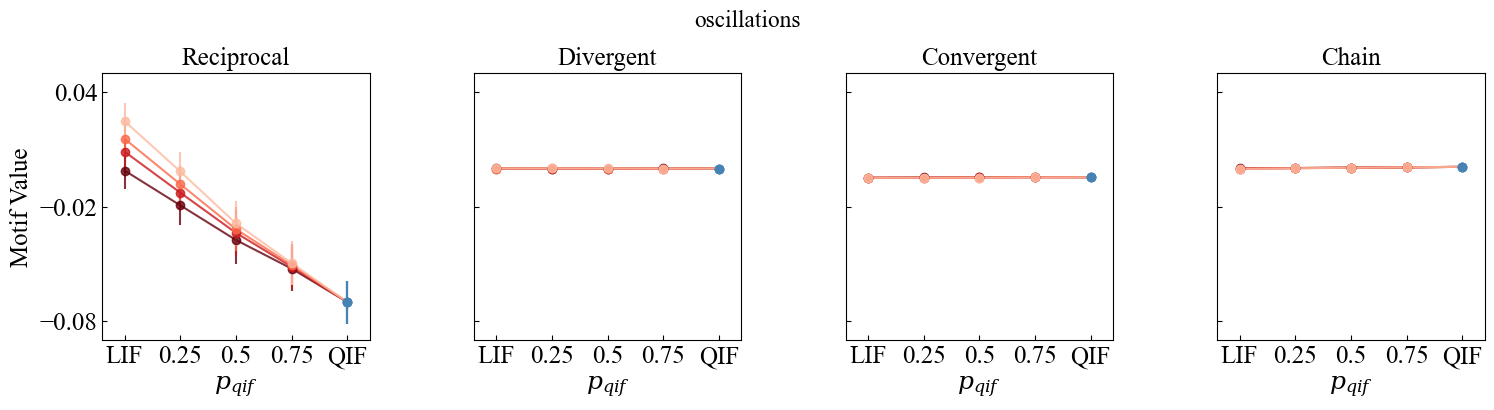

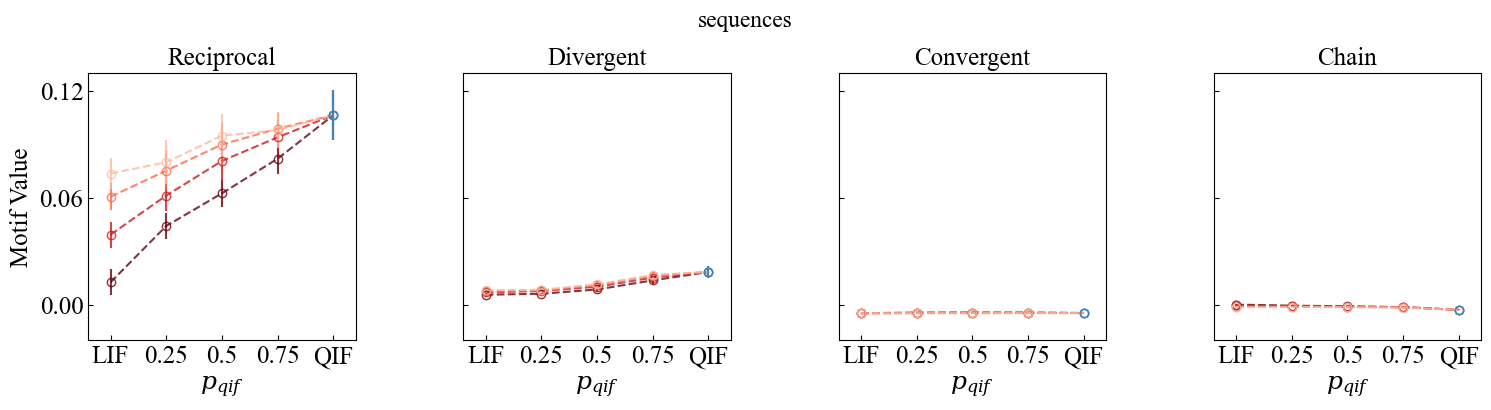

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------

# Loop variables

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
dynamics = ["oscillations", "sequences"]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']


# ------------------------------------------------------------

# Labels

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

# ------------------------------------------------------------

# Path handling

df_motif = pd.read_csv("motif_data.csv")  # The csv made with all motif data
figure_folder = 'V2/final_figures_thesis'  # Figure path
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------

# Plotting loop

for dyn in dynamics:
    figname = f"{dyn}_motifs"


    simulation_number, linestyle = (  # Linestyle for each dynamics
        (range(1, 5), "-") if dyn == "oscillations"
        else (range(9, 13), "--")
    )

    fillstyle = "full" if dyn == "oscillations" else "none" # Marker fill style for each dynamics


    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for sim, vr, f in zip(simulation_number, vrest, slope):

        xs = pqif_values
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        for pqif in pqif_values:

            # Get all data

            sim_for_qif = simulation_number[0] if pqif == 1 else sim

            df_filtered = df_motif[
                (df_motif["pqif"] == pqif)
                & (df_motif["sim"] == sim_for_qif)
                & (df_motif["nloop"] == 15)
            ]

            stats = df_filtered[motifs].agg(["mean", "std"])

            for motif in motifs:
                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        # Color
        point_colors = [
            color_map_vrest[vr] if pqif < 1 else "steelblue"
            for pqif in pqif_values
        ]

        for i, motif in enumerate(motifs):
            # Plot errorbar points and line through
            ax = axs[i]

            # line through all points
            ax.plot(
                xs,
                ys[motif],
                linestyle=linestyle,
                color=color_map_vrest[vr],
                alpha=0.8,
                label=f,
            )

            # colored errorbars on top
            for x, y, yerr, c in zip(xs, ys[motif], yerrs[motif], point_colors):
                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    marker="o",
                    fillstyle=fillstyle,
                    linestyle="none",
                    color=c,
                    ecolor=c,
                    alpha=0.8,
                )

            # ax.axhline(0, linewidth=0.2, color="black")
            if dyn == 'oscillations':
                ax.set_yticks(np.linspace(-0.08, 0.04, 3))
                ax.set_ylim(-0.09, 0.05)
            else:
                ax.set_yticks(np.linspace(0, 0.12, 3))
                ax.set_ylim(-0.02, 0.13)
            ax.set_xticks(pqif_values, names)
            ax.set_xlim(-0.1, 1.1)
            ax.set_title(motif_labels[motif])
            ax.set_box_aspect(1)
            ax.set_xlabel(r"$p_{qif}$")

    axs[0].set_ylabel("Motif Value")
    fig.suptitle(dyn)
    fig.tight_layout()
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()

In [22]:
print(np.linspace(-0.08, 0.02, 3))
print(np.linspace(-0.06, 0.04, 3))
print(np.linspace(0, 0.12, 3))

[-0.08 -0.03  0.02]
[-0.06 -0.01  0.04]
[0.   0.06 0.12]


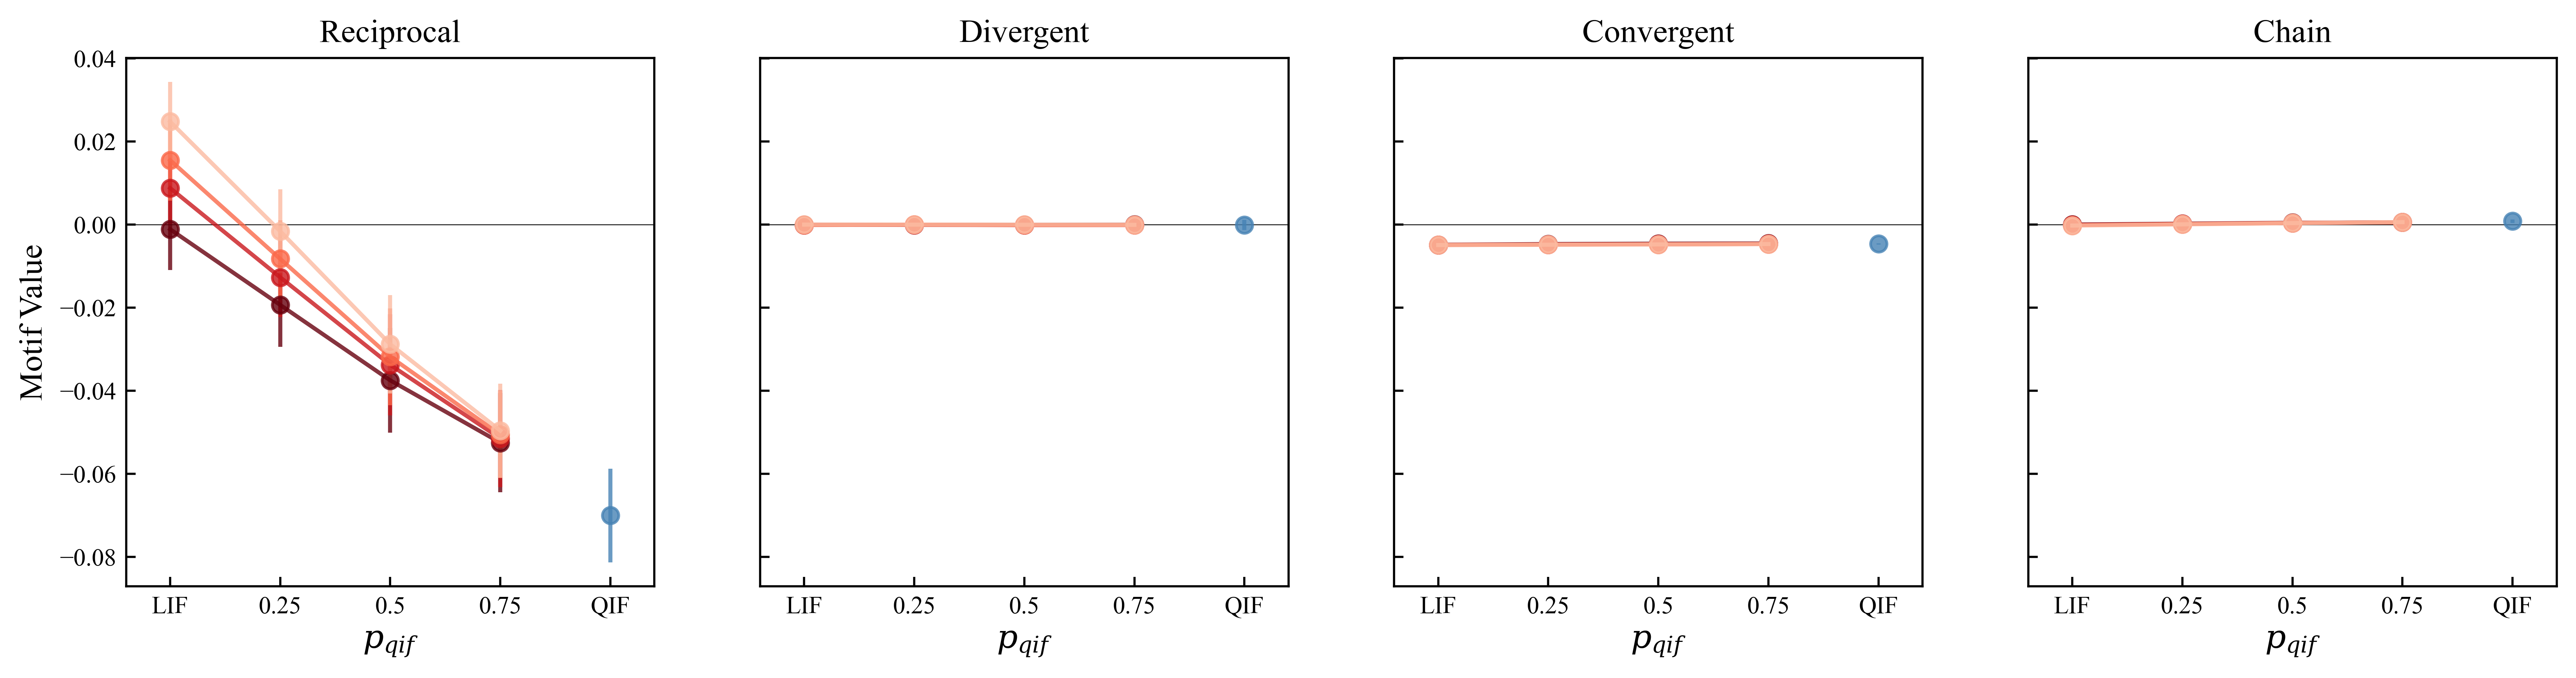

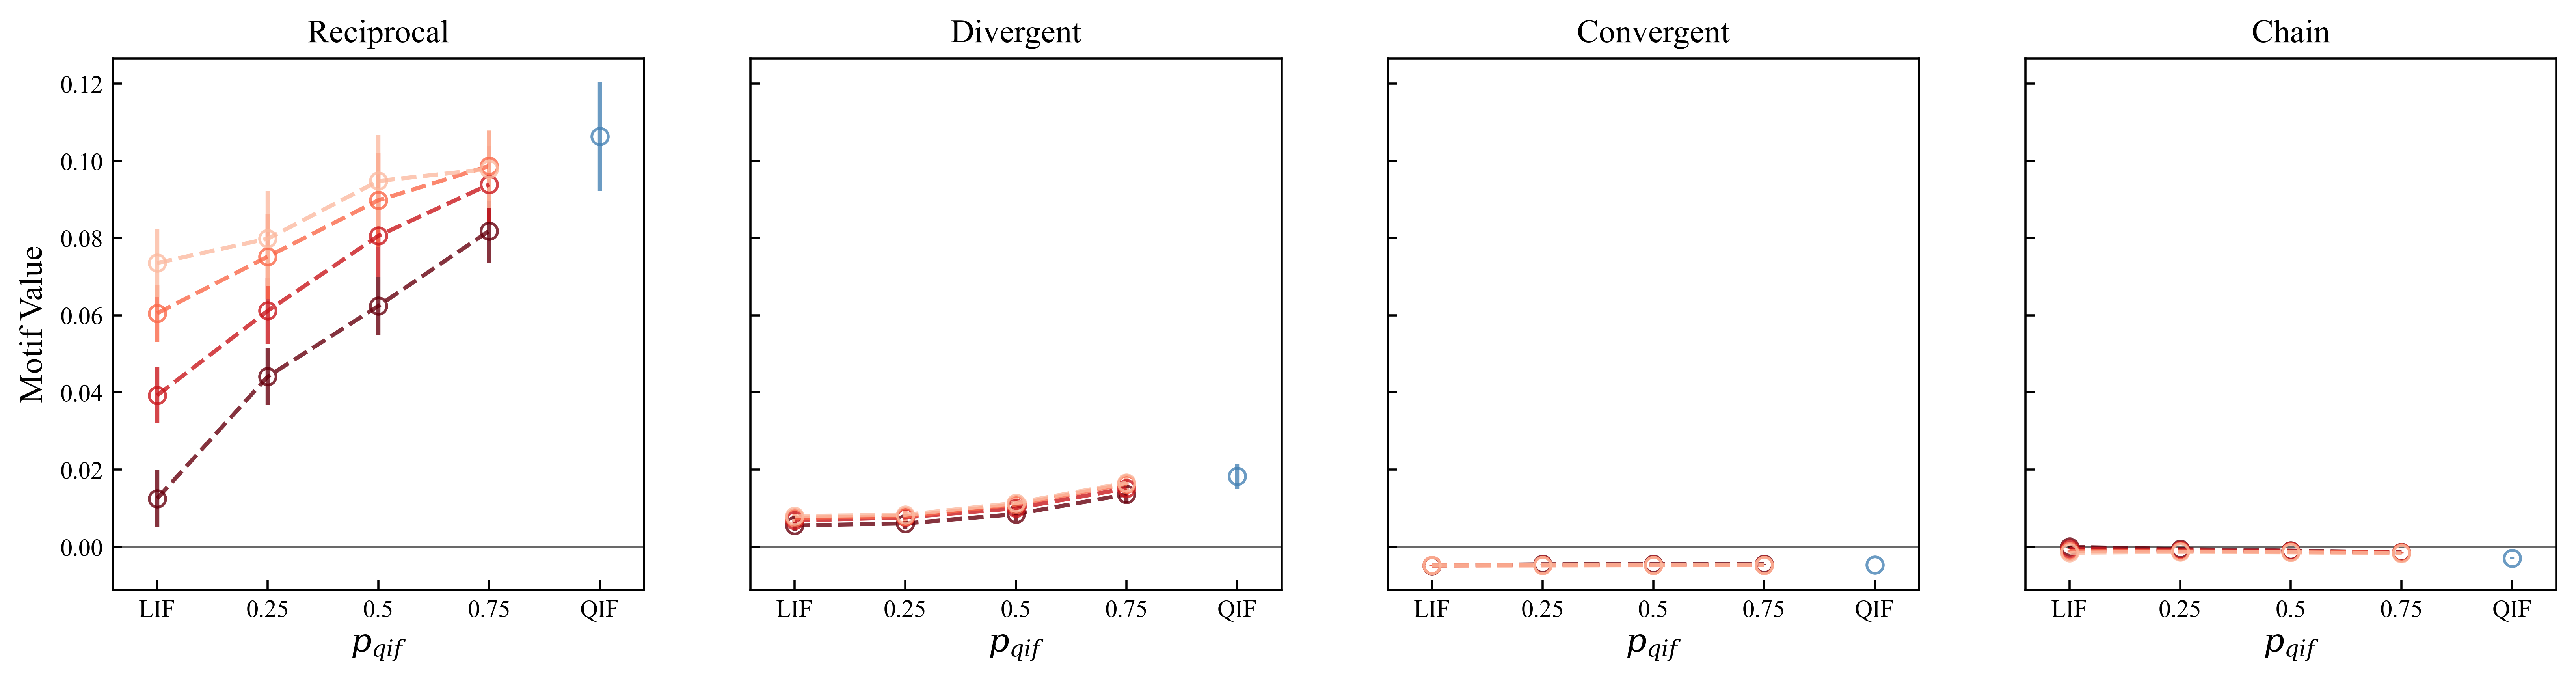

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

dynamics = ["oscillations", "sequences"]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

motif_csv_path = 'motif_data.csv'

df_motif = pd.read_csv(motif_csv_path)

for dyn in dynamics:

    simulation_number, linestyle = ([i for i in range(1,5)], '-') if dyn == 'oscillations' else ([i for i in range(9,13)], '--')


    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    figname = f"{dyn}_heterogenous_motifs.svg"



    for sim, vr, f in zip(simulation_number, vrest, slope):


        df_results = df_motif.copy()

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['sim'] == sim) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds


            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        fillstyle = 'full' if dyn == 'oscillations' else 'none'

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                fillstyle=fillstyle,
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, linewidth=0.2, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_xlim(-0.1, 1.1)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            axs[i].set_xlabel(f"$p_{{qif}}$")
            # axs[i].set_ylim()
            

    # QIF separate
    df_qif = df_results[(df_results['pqif'] == 1)  & (df_results['sim'] == simulation_number[0]) & (df_results['nloop'] == 15)] 

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}

    axs[0].set_ylabel(f"Motif Value")


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            fillstyle=fillstyle,
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    

    plt.show

## DF made in loop
Old version

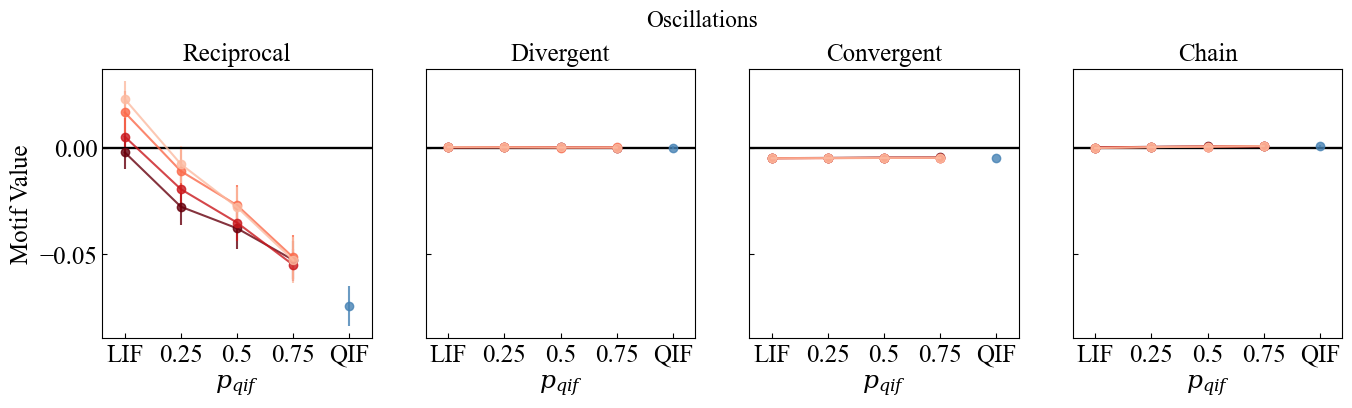

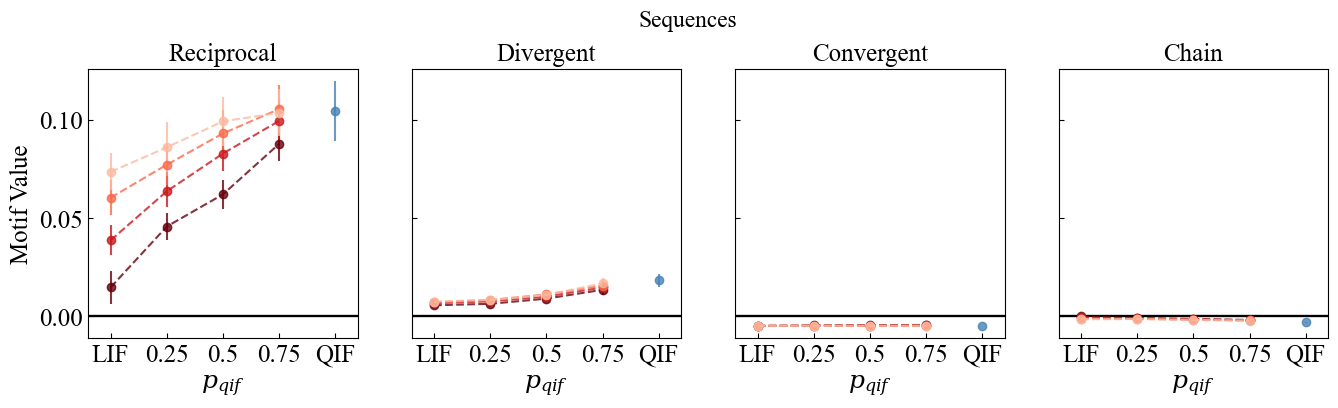

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    figname = f"{dyn}_heterogenous_motifs.svg"



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_xlim(-0.1, 1.1)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            axs[i].set_xlabel(f"$p_{{qif}}$")
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}

    axs[0].set_ylabel(f"Motif Value")


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    # plt.legend()
    plt.suptitle(f"{dyn.capitalize()}")
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show